# 라이브러리

In [ ]:
! pip3 install koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 43.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 데이터 불러오기

In [ ]:
log_path = "/content/drive/MyDrive/log_df.csv"
log_df = pd.read_csv(log_path)

In [ ]:
# 1. UTC 제거
log_df["timestamp_clean"] = log_df["timestamp"].str.replace(" UTC", "", regex=False)

# 2. datetime으로 변환
log_df["timestamp_clean"] = pd.to_datetime(
    log_df["timestamp_clean"],
    format="%Y-%m-%d %H:%M:%S.%f",
    errors="coerce"
)

# 3. NaT가 생긴 경우, 포맷이 다른 문자열을 다시 처리 (마이크로초 없는 경우 등)
mask_failed = log_df["timestamp_clean"].isna()
log_df.loc[mask_failed, "timestamp_clean"] = pd.to_datetime(
    log_df.loc[mask_failed, "timestamp"].str.replace(" UTC", "", regex=False),
    format="%Y-%m-%d %H:%M:%S",
    errors="coerce"
)

# 4. 정리
log_df["timestamp"] = log_df["timestamp_clean"]
log_df.drop(columns="timestamp_clean", inplace=True)

In [ ]:
# 쿼리 파라미터 제거
log_df["cleaned_url"] = log_df["URL"].str.split("?").str[0]

# Acquisition

In [ ]:
cleaned_unique_urls = log_df["cleaned_url"].unique()

acquisition_keywords = [
    "signup",
    "signup/step1",
    "signup/step2",
    "signup/step3",
    "api/signup"
]

# Acquisition URL로 분류
acquisition_urls = [url for url in cleaned_unique_urls if isinstance(url, str) and any(kw in url for kw in acquisition_keywords)]

In [ ]:
# 가입 관련 URL 방문 로그 추출
acquisition_logs = log_df[log_df["cleaned_url"].isin(acquisition_urls)]

# Acquisition 퍼널 세분화 (done_df)

In [ ]:
# clean_url 만들기
acquisition_logs["clean_url"] = acquisition_logs["cleaned_url"].str.lower()

# 퍼널 단계 정의
funnel_stages = {
    "detail": ["detail"],
    "step1": ["signup/step1"],
    "step2": ["signup/step2"],
    "step3": ["signup/step3"]
}

# 퍼널 단계 부여 함수
def assign_funnel_stage(url):
    url = str(url).lower()
    for stage, keywords in funnel_stages.items():
        if any(k in url for k in keywords):
            return stage
    return "other"

# funnel_stage 컬럼 생성
acquisition_logs["funnel_stage"] = acquisition_logs["clean_url"].apply(assign_funnel_stage)

<ipython-input-8-de0dcc257111>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acquisition_logs["clean_url"] = acquisition_logs["cleaned_url"].str.lower()
<ipython-input-8-de0dcc257111>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acquisition_logs["funnel_stage"] = acquisition_logs["clean_url"].apply(assign_funnel_stage)


In [ ]:
detail_stage = acquisition_logs[acquisition_logs["funnel_stage"] == "detail"]
detail_members = detail_stage["user_uuid"].unique()
detail_numbers = detail_stage["user_uuid"].nunique()

detail_df = acquisition_logs[acquisition_logs['user_uuid'].isin(detail_members)].reset_index(drop=True)

# detail -> step1
step_1_stage = detail_df[detail_df["funnel_stage"] == "step1"]

step_1_members = step_1_stage["user_uuid"].unique()

step_1_stage = detail_df[detail_df["funnel_stage"] == "step1"]
step_1_members = step_1_stage["user_uuid"].unique()
step_1_numbers = step_1_stage["user_uuid"].nunique()

step_1_df = detail_df[detail_df['user_uuid'].isin(step_1_members)].reset_index(drop=True)

# step1 -> step2
step_2_stage = step_1_df[step_1_df["funnel_stage"] == "step2"]
step_2_members = step_2_stage["user_uuid"].unique()
step_2_numbers = step_2_stage["user_uuid"].nunique()

step_2_df = step_1_df[step_1_df['user_uuid'].isin(step_2_members)].reset_index(drop=True)

# step2 -> step3
step_3_stage = step_2_df[step_2_df["funnel_stage"] == "step3"]
step_3_members = step_3_stage["user_uuid"].unique()
step_3_numbers = step_3_stage["user_uuid"].nunique()

step_3_df = step_2_df[step_2_df['user_uuid'].isin(step_3_members)].reset_index(drop=True)
done_df = step_3_df[step_3_df["cleaned_url"] == "signup/step3/done"]
done_numbers = done_df["user_uuid"].nunique()

In [ ]:
done_df

,Unnamed: 0,user_uuid,URL,timestamp,date,response_code,method,cleaned_url,clean_url,funnel_stage
3,53,8a7e70cd-1630-4a8a-8303-0706af3a7908,signup/step3/done,2022-06-22 16:20:49.307512,2022-06-23,200,GET,signup/step3/done,signup/step3/done,step3
14,11953,7e92fb11-d00d-4db4-8574-bbba6355be6c,signup/step3/done,2022-06-12 06:25:55.224833,2022-06-12,200,GET,signup/step3/done,signup/step3/done,step3
29,23786,343efc9a-2de4-4dd9-b04c-9eabeb185700,signup/step3/done,2022-05-30 13:11:35.740286,2022-05-30,200,GET,signup/step3/done,signup/step3/done,step3
32,44239,998a4c65-5021-45a5-a8fb-7cc31aa49199,signup/step3/done,2022-12-17 16:34:35.697085,2022-12-18,200,GET,signup/step3/done,signup/step3/done,step3
40,45866,998a4c65-5021-45a5-a8fb-7cc31aa49199,signup/step3/done,2022-12-17 16:34:48.037666,2022-12-18,200,GET,signup/step3/done,signup/step3/done,step3
...,...,...,...,...,...,...,...,...,...,...
48074,7183166,5e4cd7af-d86e-41e2-a8b5-8e23d26c0dec,signup/step3/done,2023-10-29 04:50:31.398241,2023-10-29,200,GET,signup/step3/done,signup/step3/done,step3
48082,7183806,6e312b0c-f631-4d24-a504-22b66f2fc420,signup/step3/done,2023-03-20 06:10:12.933765,2023-03-20,200,GET,signup/step3/done,signup/step3/done,step3
48087,7184305,81cdb863-18be-4526-ac20-12517fce66ae,signup/step3/done,2023-03-20 02:19:47.301448,2023-03-20,200,GET,signup/step3/done,signup/step3/done,step3
48099,7185883,baf3c121-cbae-42ae-88f3-2a016a096193,signup/step3/done,2023-02-01 12:20:55.938424,2023-02-01,200,GET,signup/step3/done,signup/step3/done,step3


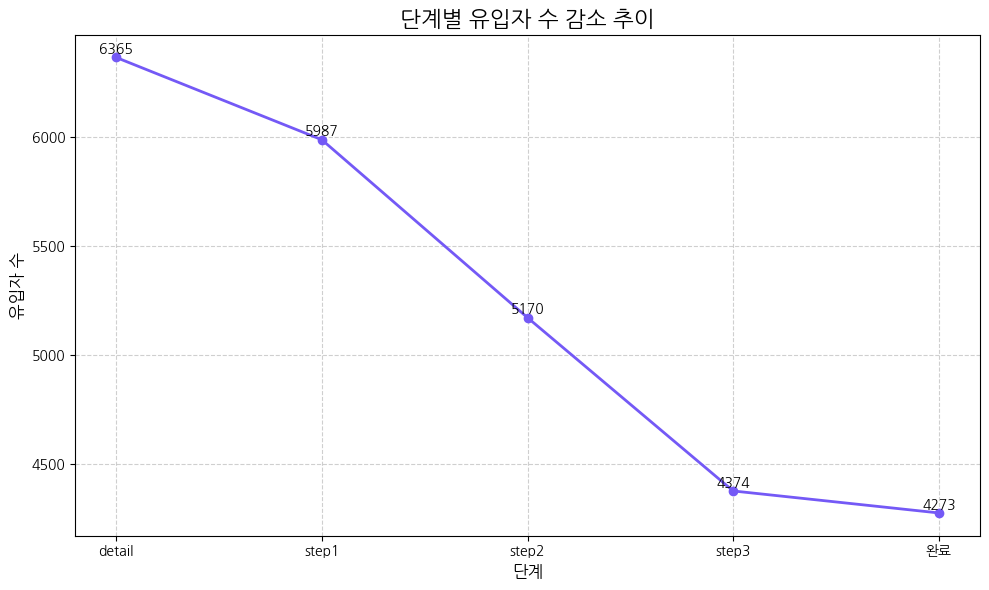

In [ ]:
# 단계 이름과 유입자 수 (너의 실제 값으로 바꿔줘)
stage_names = ["detail", "step1", "step2", "step3", "완료"]
counts = [detail_numbers, step_1_numbers, step_2_numbers, step_3_numbers, done_numbers]

# 선 그래프 그리기
plt.figure(figsize=(10, 6))
plt.plot(stage_names, counts, marker='o', linestyle='-', color='#7459f6', linewidth=2)
plt.title("단계별 유입자 수 감소 추이", fontsize=16)
plt.xlabel("단계", fontsize=12)
plt.ylabel("유입자 수", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# 각 점에 유입자 수 표시
for i, count in enumerate(counts):
    plt.text(i, count + 20, str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
del detail_stage
del detail_members
del detail_df
del step_1_stage
del step_1_members
del step_1_df
del step_2_stage
del step_2_members
del step_2_df
del step_3_stage
del step_3_members
del step_3_df

# Activation 퍼널 세분화 (apply_step_4_api_df)

In [ ]:
cleaned_unique_urls = log_df["cleaned_url"].unique()

activation_keywords = ["jobs/id/apply"]

# activation_urls URL로 분류
activation_urls = [url for url in cleaned_unique_urls if isinstance(url, str) and any(kw in url for kw in activation_keywords)]

singup_done_members = done_df["user_uuid"].unique()
acquisition_to_activation_df = log_df[log_df["user_uuid"].isin(singup_done_members)]

# 지원 관련 URL 방문 로그 추출
activation_logs = acquisition_to_activation_df[acquisition_to_activation_df["cleaned_url"].isin(activation_urls)]

In [ ]:
# 회원가입 완료한 사람 (detail, step1, 2, 3 모두 가보고 done으로 도달한 사람)
done_df["user_uuid"].nunique()

4273

In [ ]:
# 회원가입 한 4273명 중에서 apply(지원)을 시도한 사람의 수
activation_logs["user_uuid"].nunique()

4153

In [ ]:
activation_logs = activation_logs.sort_values("timestamp")

apply_step_1_df = activation_logs[activation_logs["cleaned_url"] == "jobs/id/apply/step1"]

apply_step_1_number = apply_step_1_df["user_uuid"].nunique()

apply_step_1_members = apply_step_1_df["user_uuid"].unique()

step_1_df = activation_logs[activation_logs["user_uuid"].isin(apply_step_1_members)]

apply_step_2_df = step_1_df[step_1_df["cleaned_url"] == "jobs/id/apply/step2"]

apply_step_2_number = apply_step_2_df["user_uuid"].nunique()

apply_step_2_members = apply_step_2_df["user_uuid"].unique()

step_2_df = activation_logs[activation_logs["user_uuid"].isin(apply_step_2_members)]

apply_step_3_df = step_2_df[step_2_df["cleaned_url"] == "jobs/id/apply/step3"]

apply_step_3_number = apply_step_3_df["user_uuid"].nunique()

apply_step_3_members = apply_step_3_df["user_uuid"].unique()

step_3_df = activation_logs[activation_logs["user_uuid"].isin(apply_step_3_members)]

apply_step_4_df = step_3_df[step_3_df["cleaned_url"] == "jobs/id/apply/step4"]

apply_step_4_number = apply_step_4_df["user_uuid"].nunique()

apply_step_4_members = apply_step_4_df["user_uuid"].unique()

step_4_df = activation_logs[activation_logs["user_uuid"].isin(apply_step_4_members)]

apply_step_4_api_df = step_4_df[step_4_df["cleaned_url"] == "api/jobs/id/apply/step4"]

apply_step_4_api_number = apply_step_4_api_df["user_uuid"].nunique()

In [ ]:
del activation_logs
del apply_step_1_df
del apply_step_1_members
del step_1_df
del apply_step_2_df
del apply_step_2_members
del step_2_df
del apply_step_3_df
del apply_step_3_members
del step_3_df
del apply_step_4_df
del apply_step_4_members
del step_4_df

In [ ]:
# 단계별 유입자 수
stage_names = ["step1", "step2", "step3", "step4", "완료"]
counts = [apply_step_1_number, apply_step_2_number, apply_step_3_number, apply_step_4_number, apply_step_4_api_number]

# 기준이 되는 상세 페이지 진입 수
base_number = counts[0]

# 백분율 계산: 각 단계의 유입자 수 / 상세 페이지 진입 수 * 100
percentage_rates = [round((count / base_number) * 100, 2) for count in counts]

# 이탈률 계산
dropoff_rates = []
for i in range(len(counts) - 1):
    rate = (counts[i] - counts[i+1]) / counts[i]
    dropoff_rates.append(round(rate * 100, 2))
dropoff_rates.append(0.0)  # 완료 단계에서는 이탈률 없음

# 표 생성
df = pd.DataFrame({
    "단계": stage_names,
    "유입자 수": counts,
    "이탈률 (%)": dropoff_rates,
    "백분율 (%)": percentage_rates
})

df

,단계,유입자 수,이탈률 (%),백분율 (%)
0,step1,4145,0.68,100.00
1,step2,4117,11.61,99.32
2,step3,3639,0.41,87.79
3,step4,3624,0.06,87.43
4,완료,3622,0.00,87.38


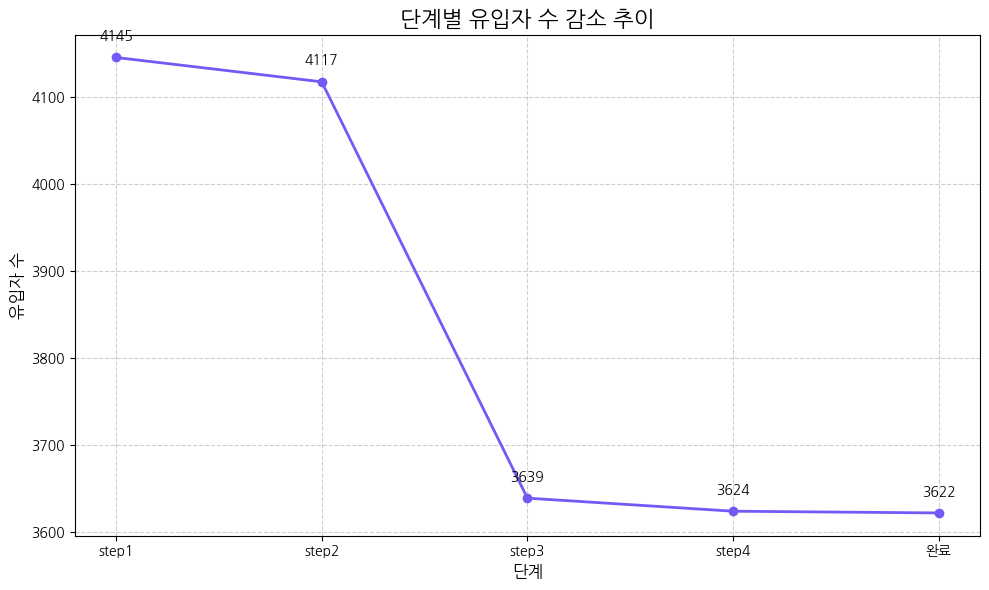

In [ ]:
# 단계 이름과 유입자 수 (너의 실제 값으로 바꿔줘)
stage_names = ["step1", "step2", "step3", "step4", "완료"]
counts = [apply_step_1_number, apply_step_2_number, apply_step_3_number, apply_step_4_number, apply_step_4_api_number]

# 선 그래프 그리기
plt.figure(figsize=(10, 6))
plt.plot(stage_names, counts, marker='o', linestyle='-', color='#7459f6', linewidth=2)
plt.title("단계별 유입자 수 감소 추이", fontsize=16)
plt.xlabel("단계", fontsize=12)
plt.ylabel("유입자 수", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# 각 점에 유입자 수 표시
for i, count in enumerate(counts):
    plt.text(i, count + 20, str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 활성화 유저 월별 코호트 리텐션

In [ ]:
df = apply_step_4_api_df.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"])

# apply 로그만 필터링
apply_logs = df[df["cleaned_url"] == "api/jobs/id/apply/step4"]

# 유저별 최초 지원일 (코호트 기준)
apply_logs["cohort_date"] = apply_logs.groupby("user_uuid")["timestamp"].transform("min")

# 전체 로그에 유저별 cohort 정보 병합
df = df.merge(apply_logs[["user_uuid", "cohort_date"]].drop_duplicates(), on="user_uuid", how="left")

# 월 단위로 변환
df["cohort_date"] = df["cohort_date"].dt.to_period("M").apply(lambda r: r.start_time)
df["event_month"] = df["timestamp"].dt.to_period("M").apply(lambda r: r.start_time)

# 코호트 내 경과 월 계산
df["month_index"] = ((df["event_month"] - df["cohort_date"]) / pd.Timedelta(days=30)).astype(int)

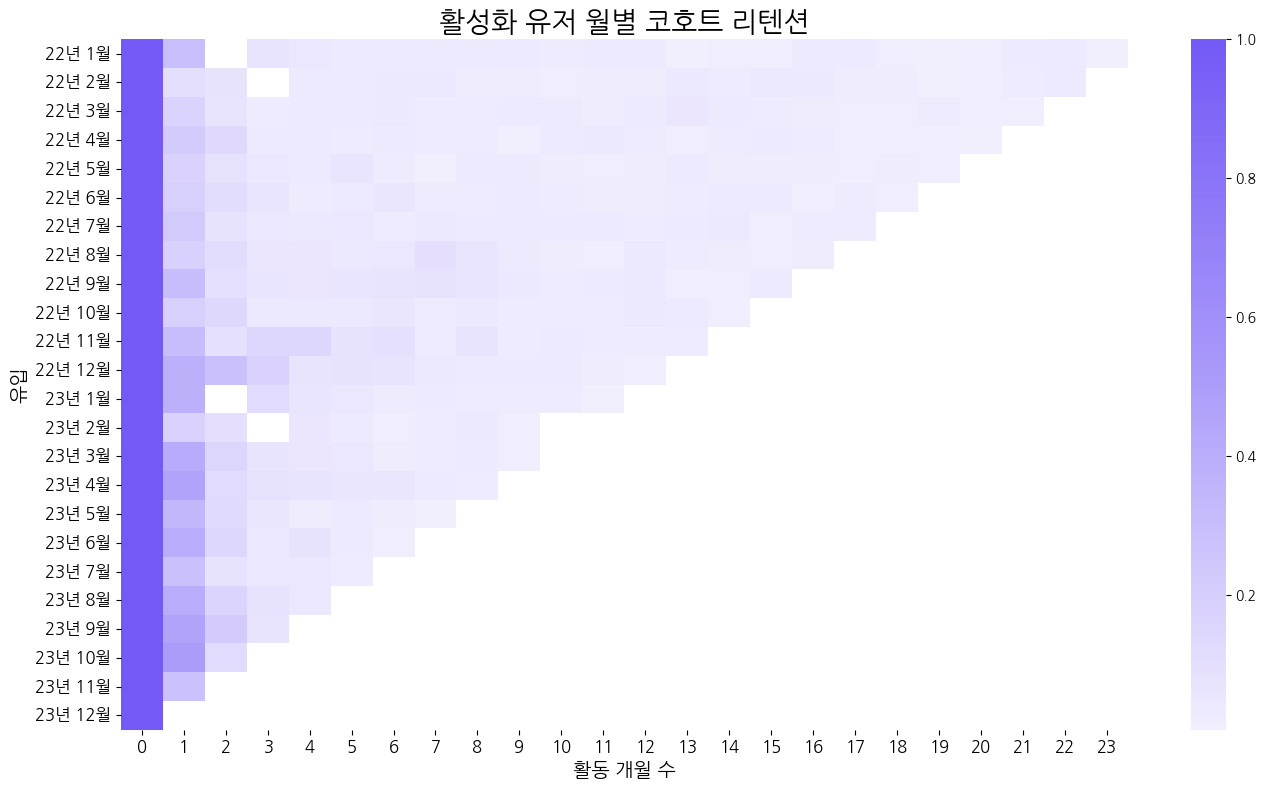

In [ ]:
# 유저 수 집계
cohort_data = df.groupby(["cohort_date", "month_index"])["user_uuid"].nunique().reset_index()

# 피벗 테이블로 변환
cohort_pivot = cohort_data.pivot(index="cohort_date", columns="month_index", values="user_uuid")

# 각 코호트의 최초 유저 수
cohort_sizes = cohort_pivot.iloc[:, 0]

# 리텐션율 계산
retention = cohort_pivot.divide(cohort_sizes, axis=0)

from matplotlib.colors import LinearSegmentedColormap

# 컬러맵
colors = ["#f1eefe", "#ac9cfa", "#7459f6"]
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)

plt.figure(figsize=(14, 8))  # 조금 더 크게
sns.heatmap(retention, annot=False, cmap=custom_cmap)

# 제목과 축 폰트 사이즈 조정
plt.title("활성화 유저 월별 코호트 리텐션", fontsize=20)
plt.xlabel("활동 개월 수", fontsize=14)
plt.ylabel("유입", fontsize=14)

# y축 날짜 포맷 수정
new_labels = [f"{d.year % 100}년 {d.month}월" for d in retention.index]
plt.yticks(ticks=np.arange(len(new_labels)) + 0.5, labels=new_labels, fontsize=12)

# x축, y축 눈금 글자 크기 키우기
plt.xticks(fontsize=12)  # x축 살짝 기울이기
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

# 합격자

## 최종 합격한 사람 (@user_id/applications?status=passed)

In [ ]:
log_passed_members = log_df[log_df['URL'] == "@user_id/applications?status=passed"]["user_uuid"].unique()

finally_passed_df = apply_step_4_api_df[apply_step_4_api_df['user_uuid'].isin(log_passed_members)]
finally_passed_df

,Unnamed: 0,user_uuid,URL,timestamp,date,response_code,method,cleaned_url
2436490,2436490,c003e946-1735-45fd-8705-7c01cca13654,api/jobs/id/apply/step4,2022-01-11 15:59:55.871142,2022-01-12,200,POST,api/jobs/id/apply/step4
2437561,2437561,c003e946-1735-45fd-8705-7c01cca13654,api/jobs/id/apply/step4,2022-01-11 16:01:04.856163,2022-01-12,200,POST,api/jobs/id/apply/step4
2437586,2437586,c003e946-1735-45fd-8705-7c01cca13654,api/jobs/id/apply/step4,2022-01-11 16:10:11.409391,2022-01-12,200,POST,api/jobs/id/apply/step4
2437801,2437801,c003e946-1735-45fd-8705-7c01cca13654,api/jobs/id/apply/step4,2022-01-11 16:12:50.983437,2022-01-12,200,POST,api/jobs/id/apply/step4
2438051,2438051,c003e946-1735-45fd-8705-7c01cca13654,api/jobs/id/apply/step4,2022-01-11 16:21:40.009640,2022-01-12,200,POST,api/jobs/id/apply/step4
...,...,...,...,...,...,...,...,...
10376278,322154,cbb20503-3862-42c9-ac13-e3975dcdfda5,api/jobs/id/apply/step4,2023-12-29 07:56:51.010307,2023-12-29,200,POST,api/jobs/id/apply/step4
10376323,322199,cbb20503-3862-42c9-ac13-e3975dcdfda5,api/jobs/id/apply/step4,2023-12-29 08:00:18.772876,2023-12-29,200,POST,api/jobs/id/apply/step4
10286582,232458,817bc209-a0f0-4be1-a9f3-bdd3589cad5e,api/jobs/id/apply/step4,2023-12-29 08:14:56.778451,2023-12-29,200,POST,api/jobs/id/apply/step4
10286604,232480,817bc209-a0f0-4be1-a9f3-bdd3589cad5e,api/jobs/id/apply/step4,2023-12-29 08:38:18.878372,2023-12-29,200,POST,api/jobs/id/apply/step4


In [ ]:
apply_step_4_api_df["user_uuid"].nunique()

3622

In [ ]:
finally_passed_df["user_uuid"].nunique()

317

In [ ]:
finally_passed_members = finally_passed_df["user_uuid"].unique()

## 최종 합격자 제외 인터뷰 합격자

In [ ]:
not_finally_passed_df = apply_step_4_api_df[~apply_step_4_api_df["user_uuid"].isin(finally_passed_members)]

not_finally_passed_members = not_finally_passed_df["user_uuid"].unique()

log_interview_passed_members = log_df[log_df['URL'] == "@user_id/applications?status=interview-passed"]["user_uuid"].unique()

interview_passed_df = not_finally_passed_df[not_finally_passed_df['user_uuid'].isin(log_interview_passed_members)]

In [ ]:
len(not_finally_passed_members)

3305

In [ ]:
interview_passed_df["user_uuid"].nunique()

126

In [ ]:
interview_passed_members = interview_passed_df["user_uuid"].unique()

## 인터뷰 합격자 제외 서류 합격자

In [ ]:
not_interview_passed_df = not_finally_passed_df[~not_finally_passed_df["user_uuid"].isin(interview_passed_members)]

not_interview_passed_members = not_interview_passed_df["user_uuid"].unique()

log_application_passed_members = log_df[log_df['URL'] == "@user_id/applications?status=application-passed"]["user_uuid"].unique()

application_passed_df = not_interview_passed_df[not_interview_passed_df['user_uuid'].isin(log_application_passed_members)]

In [ ]:
not_interview_passed_df["user_uuid"].nunique()

3179

In [ ]:
application_passed_df["user_uuid"].nunique()

394

In [ ]:
application_passed_members = application_passed_df["user_uuid"].unique()

## 서류 합격까지 모두 제외

In [ ]:
# numpy의 set 차집합 기능 사용
losers = np.setdiff1d(
    not_interview_passed_df["user_uuid"].unique(),
    application_passed_df["user_uuid"].unique()
)

In [ ]:
len(losers)

2785

## 서류 합격 (total_application_passed_df) vs 불합격 (total_losers_df)

In [ ]:
total_application_passed_members = apply_step_4_api_df[~apply_step_4_api_df["user_uuid"].isin(losers)]["user_uuid"].unique()
total_application_passed_df = log_df[log_df["user_uuid"].isin(total_application_passed_members)]
total_losers_df = log_df[log_df["user_uuid"].isin(losers)]

In [ ]:
apply_step_4_api_df["user_uuid"].nunique()

3622

In [ ]:
total_application_passed_df["user_uuid"].nunique()

837

In [ ]:
total_losers_df["user_uuid"].nunique()

2785

## 페이지별 체류시간

In [ ]:
step_keywords = ['step1', 'step2', 'step3', 'step4']

step_mask = log_df["cleaned_url"].apply(
    lambda url: isinstance(url, str) and any(kw in url for kw in step_keywords)
)
step_logs = log_df[step_mask].copy()

# 2. user + timestamp 기준 정렬 후 체류 시간 계산
step_logs = step_logs.sort_values(by=["user_uuid", "timestamp"])
step_logs["next_timestamp"] = step_logs.groupby("user_uuid")["timestamp"].shift(-1)
step_logs["stay_duration"] = (step_logs["next_timestamp"] - step_logs["timestamp"]).dt.total_seconds()

# 3. step 추출: numpy array + vectorized 방식
step_map = {kw: kw for kw in step_keywords}
step_logs["step"] = np.select(
    [step_logs["cleaned_url"].str.contains(kw, na=False) for kw in step_keywords],
    step_keywords,
    default="기타"
)

# 4. 상태 분류: set을 활용한 빠른 조회
passed_users = set(total_application_passed_df["user_uuid"])
failed_users = set(total_losers_df["user_uuid"])

def classify_status(user_uuid):
    if user_uuid in passed_users:
        return "합격자"
    elif user_uuid in failed_users:
        return "불합격자"
    else:
        return "기타"

step_logs["status"] = step_logs["user_uuid"].map(classify_status)

# 5. 체류시간 2초 이하 제거
step_logs = step_logs[step_logs["stay_duration"] > 2]

# 6. 최종 평균 체류시간 계산
step_time_stats = step_logs[step_logs["status"].isin(["합격자", "불합격자"])] \
    .groupby(["status", "step"])["stay_duration"].mean().reset_index()

# 초 → 분 변환
step_time_stats["stay_duration_minutes"] = (step_time_stats["stay_duration"] / 60).round(2)

# 결과 보기 좋게 정리
step_time_stats = step_time_stats[["status", "step", "stay_duration_minutes"]]

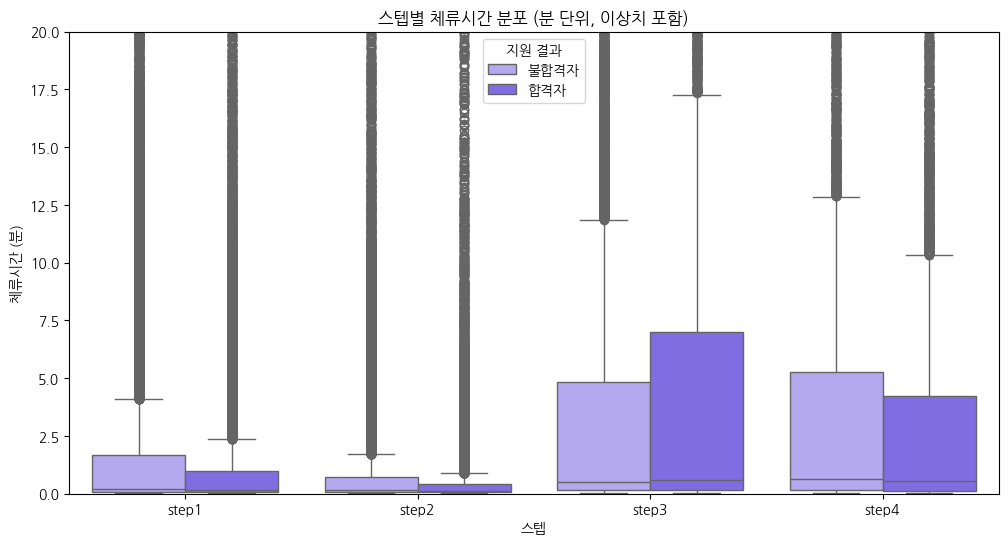

In [ ]:
# 체류시간을 분 단위로 변환
step_logs["stay_minutes"] = (step_logs["stay_duration"] / 60).round(2)

# 합격자/불합격자 중에서만 확인
filtered = step_logs[step_logs["status"].isin(["합격자", "불합격자"])]

# 컬러맵 설정
custom_palette = {"불합격자": "#ac9cfa", "합격자": "#7459f6"}

# Boxplot으로 이상치 확인
plt.figure(figsize=(12, 6))
sns.boxplot(data=filtered, x="step", y="stay_minutes", hue="status", palette=custom_palette)
plt.ylim(0, 20)
plt.title("스텝별 체류시간 분포 (분 단위, 이상치 포함)")
plt.ylabel("체류시간 (분)")
plt.xlabel("스텝")
plt.legend(title="지원 결과")
plt.show()

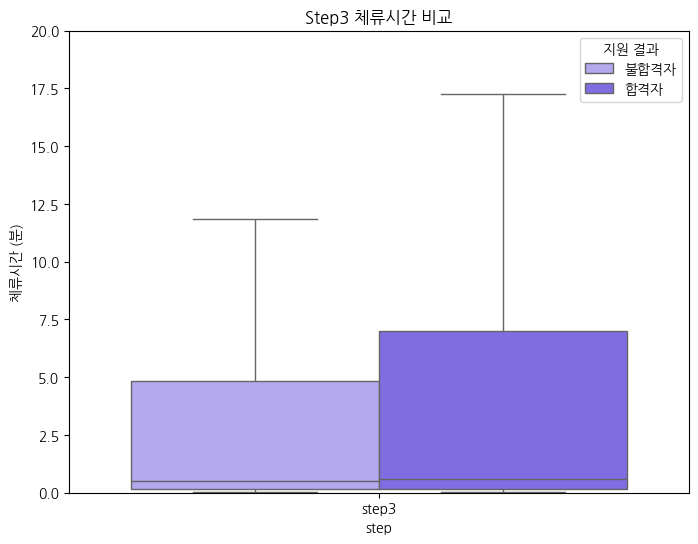

In [ ]:
# step3 데이터만 필터링
step3_data = filtered[filtered["step"] == "step3"]

# 컬러맵 유지
custom_palette = {
    "불합격자": "#ac9cfa",
    "합격자": "#7459f6"
}

# 박스플롯 그리기 (이상치 제거: showfliers=False)
plt.figure(figsize=(8, 6))
sns.boxplot(data=step3_data, x="step", y="stay_minutes", hue="status", palette=custom_palette, showfliers=False)
plt.ylim(0, 20)
plt.title("Step3 체류시간 비교")
plt.ylabel("체류시간 (분)")
plt.legend(title="지원 결과")
plt.show()

In [ ]:
from scipy.stats import ttest_ind

# 합격자와 불합격자 체류시간 추출
step3_passed = step3_data[step3_data["status"] == "합격자"]["stay_minutes"]
step3_failed = step3_data[step3_data["status"] == "불합격자"]["stay_minutes"]

# t-test 수행 (등분산 가정하지 않음 → Welch's t-test)
t_stat, p_value = ttest_ind(step3_passed, step3_failed, equal_var=False)

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("체류시간 차이가 통계적으로 유의합니다 (p < 0.05)")
else:
    print("체류시간 차이가 통계적으로 유의하지 않습니다 (p >= 0.05)")

t-statistic: -6.9296
p-value: 0.0000
체류시간 차이가 통계적으로 유의합니다 (p < 0.05)


In [ ]:
# 체류시간 분 단위로 변환
step_logs["stay_minutes"] = step_logs["stay_duration"] / 60
filtered = step_logs[step_logs["status"].isin(["합격자", "불합격자"])]

# 이상치 제거 함수 정의
def remove_iqr_outliers(df):
    result = []

    for (status, step), group in df.groupby(["status", "step"]):
        q1 = group["stay_minutes"].quantile(0.25)
        q3 = group["stay_minutes"].quantile(0.75)
        iqr = q3 - q1
        upper_bound = q3 + 1.5 * iqr
        lower_bound = q1 - 1.5 * iqr

        cleaned_group = group[(group["stay_minutes"] <= upper_bound) & (group["stay_minutes"] >= lower_bound)].copy()
        result.append(cleaned_group)

    return pd.concat(result)

# IQR 기반 이상치 제거
filtered_clean = remove_iqr_outliers(filtered)

# 이상치 제거 후 평균 체류시간 재계산
mean_stats_iqr = filtered_clean.groupby(["status", "step"])["stay_minutes"].mean().reset_index()
mean_stats_iqr["stay_minutes"] = mean_stats_iqr["stay_minutes"].round(2)

mean_stats_iqr

,status,step,stay_minutes
0,불합격자,step1,0.47
1,불합격자,step2,0.30
2,불합격자,step3,1.12
3,불합격자,step4,1.16
4,합격자,step1,0.28
5,합격자,step2,0.17
6,합격자,step3,1.58
7,합격자,step4,1.04


## 합격자 vs 불합격자 리텐션 분석

### 불합격자 월별 코호트 리텐션 차트 그리기

In [ ]:
loser_logs = log_df[log_df["user_uuid"].isin(total_losers_df["user_uuid"])].copy()

loser_logs["timestamp"] = pd.to_datetime(loser_logs["timestamp"])
loser_logs["activity_month"] = loser_logs["timestamp"].dt.to_period("M").dt.to_timestamp()


loser_logs["cohort_month"] = loser_logs.groupby("user_uuid")["timestamp"].transform("min").dt.to_period("M").dt.to_timestamp()


loser_logs["month_index"] = (
    (loser_logs["activity_month"].dt.to_period("M") - loser_logs["cohort_month"].dt.to_period("M"))
).apply(lambda x: x.n)

#  코호트별 월간 활동 유저 수 계산
cohort_counts = loser_logs.groupby(["cohort_month", "month_index"])["user_uuid"].nunique().reset_index()
cohort_pivot = cohort_counts.pivot(index="cohort_month", columns="month_index", values="user_uuid")

# 리텐션율 계산
cohort_sizes = cohort_pivot[0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0).round(3)

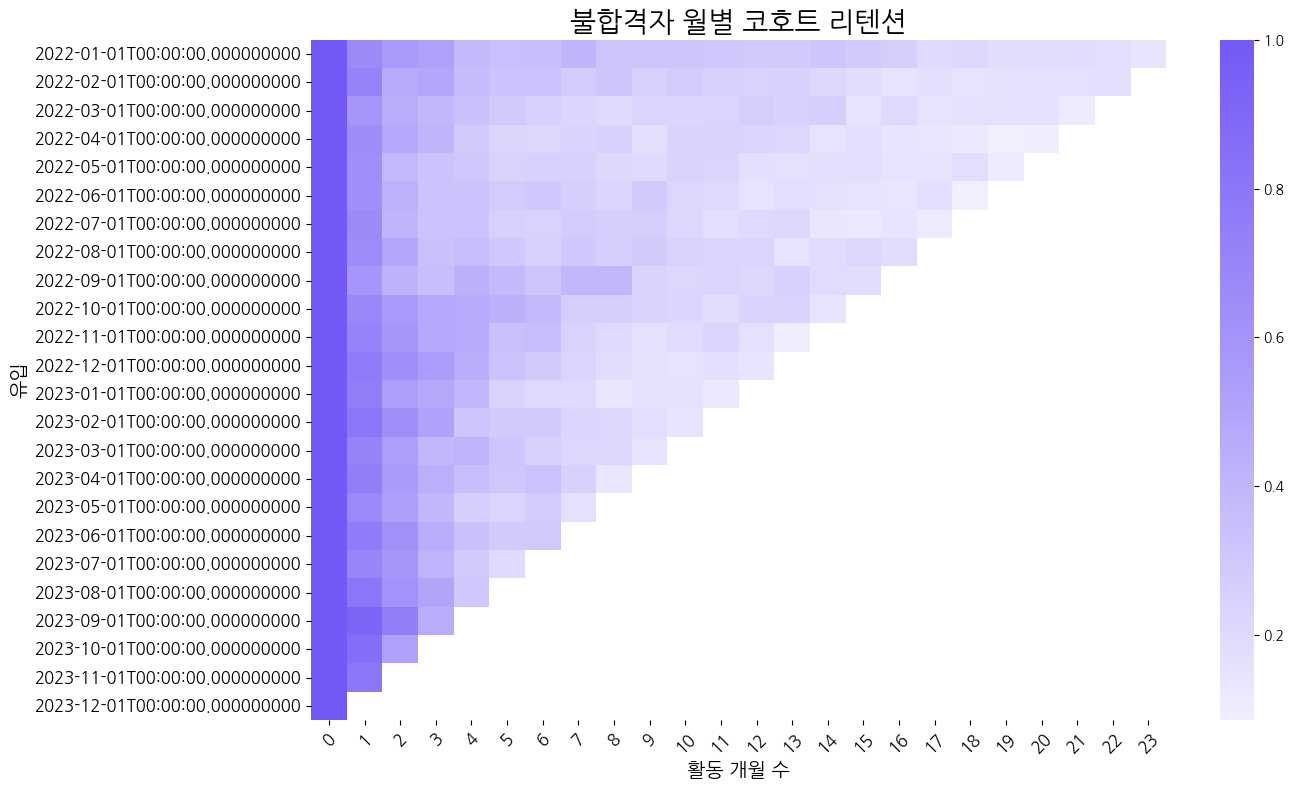

In [ ]:
plt.figure(figsize=(14, 8))  # 조금 더 크게
sns.heatmap(retention_matrix, annot=False, cmap=custom_cmap)

# 제목과 축 폰트 사이즈 조정
plt.title("불합격자 월별 코호트 리텐션", fontsize=20)
plt.xlabel("활동 개월 수", fontsize=14)
plt.ylabel("유입", fontsize=14)

# x축, y축 눈금 글자 크기 키우기
plt.xticks(fontsize=12, rotation=45)  # x축 살짝 기울이기
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

```python
plt.figure(figsize=(12, 6))
sns.heatmap(retention_matrix, annot=True, fmt=".2%", cmap="YlGnBu")
plt.title("불합격자 월별 코호트 리텐션")
plt.xlabel("활동 개월 수")
plt.ylabel("유입 ")
plt.tight_layout()
plt.show()
```

### 합격자 월별 코호트 리텐션 차트 그리기

In [ ]:
total_application_passed_df["timestamp"] = pd.to_datetime(total_application_passed_df["timestamp"])
total_application_passed_df["activity_month"] = total_application_passed_df["timestamp"].dt.to_period("M").dt.to_timestamp()


total_application_passed_df["cohort_month"] = total_application_passed_df.groupby("user_uuid")["timestamp"].transform("min").dt.to_period("M").dt.to_timestamp()


total_application_passed_df["month_index"] = (
    (total_application_passed_df["activity_month"].dt.to_period("M") - total_application_passed_df["cohort_month"].dt.to_period("M"))
).apply(lambda x: x.n)

#  코호트별 월간 활동 유저 수 계산
cohort_counts = total_application_passed_df.groupby(["cohort_month", "month_index"])["user_uuid"].nunique().reset_index()
cohort_pivot = cohort_counts.pivot(index="cohort_month", columns="month_index", values="user_uuid")

# 리텐션율 계산
cohort_sizes = cohort_pivot[0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0).round(3)

In [ ]:
# 2022-01-01 이후 코호트만 남기기
retention_matrix = retention_matrix[retention_matrix.index >= '2022-01-01']

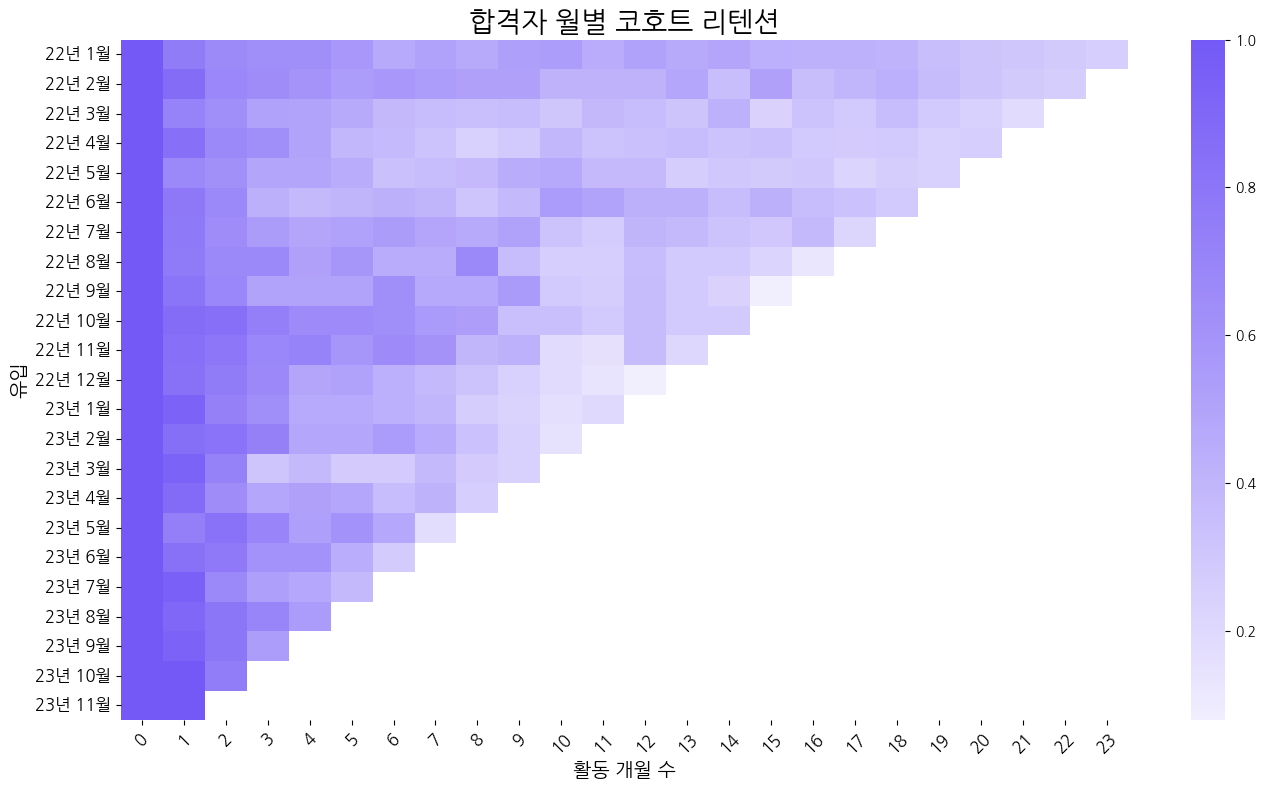

In [ ]:
plt.figure(figsize=(14, 8))
sns.heatmap(retention_matrix, annot=False, cmap=custom_cmap)

# 제목과 축 폰트 사이즈 조정
plt.title("합격자 월별 코호트 리텐션", fontsize=20)
plt.xlabel("활동 개월 수", fontsize=14)
plt.ylabel("유입", fontsize=14)

# x축, y축 눈금 글자 크기 키우기
plt.xticks(fontsize=12, rotation=45)

# y축 날짜 포맷 수정
new_labels = [f"{d.year % 100}년 {d.month}월" for d in retention_matrix.index]
plt.yticks(ticks=np.arange(len(new_labels)) + 0.5, labels=new_labels, fontsize=12)

plt.tight_layout()
plt.show()

```python
plt.figure(figsize=(12, 6))
sns.heatmap(retention_matrix, annot=True, fmt=".2%", cmap="YlGnBu")
plt.title("합격자 월별 코호트 리텐션")
plt.xlabel("활동 개월 수")
plt.ylabel("유입 ")
plt.tight_layout()
plt.show()
```

### 불합격자 수 2,785명(random_losers_df)으로 다시 해보기

In [ ]:
loser_members = total_losers_df["user_uuid"].unique()

random_loser_members = np.random.choice(loser_members, size=2785, replace=False)

random_losers_df = total_losers_df[total_losers_df["user_uuid"].isin(random_loser_members)]

In [ ]:
loser_logs = log_df[log_df["user_uuid"].isin(random_losers_df["user_uuid"])].copy()

loser_logs["timestamp"] = pd.to_datetime(loser_logs["timestamp"])
loser_logs["activity_month"] = loser_logs["timestamp"].dt.to_period("M").dt.to_timestamp()


loser_logs["cohort_month"] = loser_logs.groupby("user_uuid")["timestamp"].transform("min").dt.to_period("M").dt.to_timestamp()


loser_logs["month_index"] = (
    (loser_logs["activity_month"].dt.to_period("M") - loser_logs["cohort_month"].dt.to_period("M"))
).apply(lambda x: x.n)

#  코호트별 월간 활동 유저 수 계산
cohort_counts = loser_logs.groupby(["cohort_month", "month_index"])["user_uuid"].nunique().reset_index()
cohort_pivot = cohort_counts.pivot(index="cohort_month", columns="month_index", values="user_uuid")

# 리텐션율 계산
cohort_sizes = cohort_pivot[0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0).round(3)

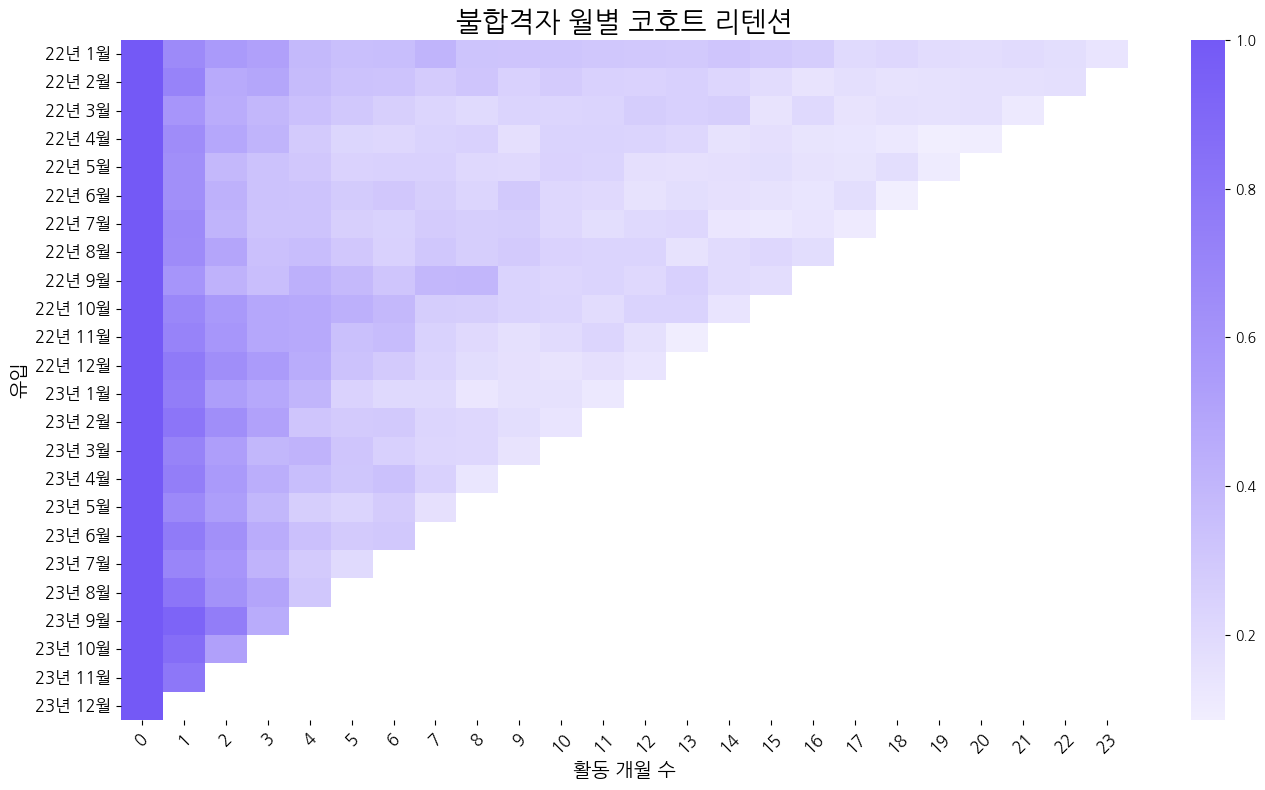

In [ ]:
plt.figure(figsize=(14, 8))
sns.heatmap(retention_matrix, annot=False, cmap=custom_cmap)

# 제목과 축 폰트 사이즈 조정
plt.title("불합격자 월별 코호트 리텐션", fontsize=20)
plt.xlabel("활동 개월 수", fontsize=14)
plt.ylabel("유입", fontsize=14)

# x축, y축 눈금 글자 크기 키우기
plt.xticks(fontsize=12, rotation=45)

# y축 날짜 포맷 수정
new_labels = [f"{d.year % 100}년 {d.month}월" for d in retention_matrix.index]
plt.yticks(ticks=np.arange(len(new_labels)) + 0.5, labels=new_labels, fontsize=12)

plt.tight_layout()
plt.show()

```python
plt.figure(figsize=(12, 6))
sns.heatmap(retention_matrix, annot=True, fmt=".2%", cmap="YlGnBu")
plt.title("랜덤 불합격자 월별 코호트 리텐션")
plt.xlabel("활동 개월 수")
plt.ylabel("유입 ")
plt.tight_layout()
plt.show()
```

## 합격자와 불합격자 중 누가 더 지원을 많이 했는가?

In [ ]:
# Step 1: 특정 cleaned_url 값 필터링
losers_apply_complete_df = total_losers_df[total_losers_df['cleaned_url'] == 'api/jobs/id/apply/step4']

# Step 2: user_uuid별로 groupby 후 count
losers_apply_complete_counts = losers_apply_complete_df.groupby('user_uuid').size()

# Step 3: 평균 계산
losers_apply_complete_average_count = losers_apply_complete_counts.mean()

print(f"불합격자의 평균 지원 완료 횟수: {losers_apply_complete_average_count}")

불합격자의 평균 지원 완료 횟수: 5.6262118491921


In [ ]:
# Step 1: 특정 cleaned_url 값 필터링
passed_apply_complete_df = total_application_passed_df[total_application_passed_df['cleaned_url'] == 'api/jobs/id/apply/step4']

# Step 2: user_uuid별로 groupby 후 count
passed_apply_complete_counts = passed_apply_complete_df.groupby('user_uuid').size()

# Step 3: 평균 계산
passed_apply_complete_average_count = passed_apply_complete_counts.mean()

print(f"합격자의 평균 지원 완료 횟수: {passed_apply_complete_average_count}")

합격자의 평균 지원 완료 횟수: 14.99641577060932


## 합불 행동 패턴 분석

In [ ]:
passed_users = set(total_application_passed_df['user_uuid'])
failed_users = set(total_losers_df['user_uuid'])


log_df['status'] = log_df['user_uuid'].apply(
    lambda x: '합격자' if x in passed_users else ('불합격자' if x in failed_users else '기타')
)

# 합격자와 불합격자의 행동 패턴 비교, URL 기준 상위 20개 행동 비교
log_counts = log_df[log_df['status'].isin(['합격자', '불합격자'])] \
    .groupby(['status', 'cleaned_url'])['user_uuid'].count().reset_index()
log_counts.columns = ['status', 'cleaned_url', 'count']

# 상위 20개 행동
top_passed = log_counts[log_counts['status'] == '합격자'].sort_values(by='count', ascending=False).head(20)
top_failed = log_counts[log_counts['status'] == '불합격자'].sort_values(by='count', ascending=False).head(20)

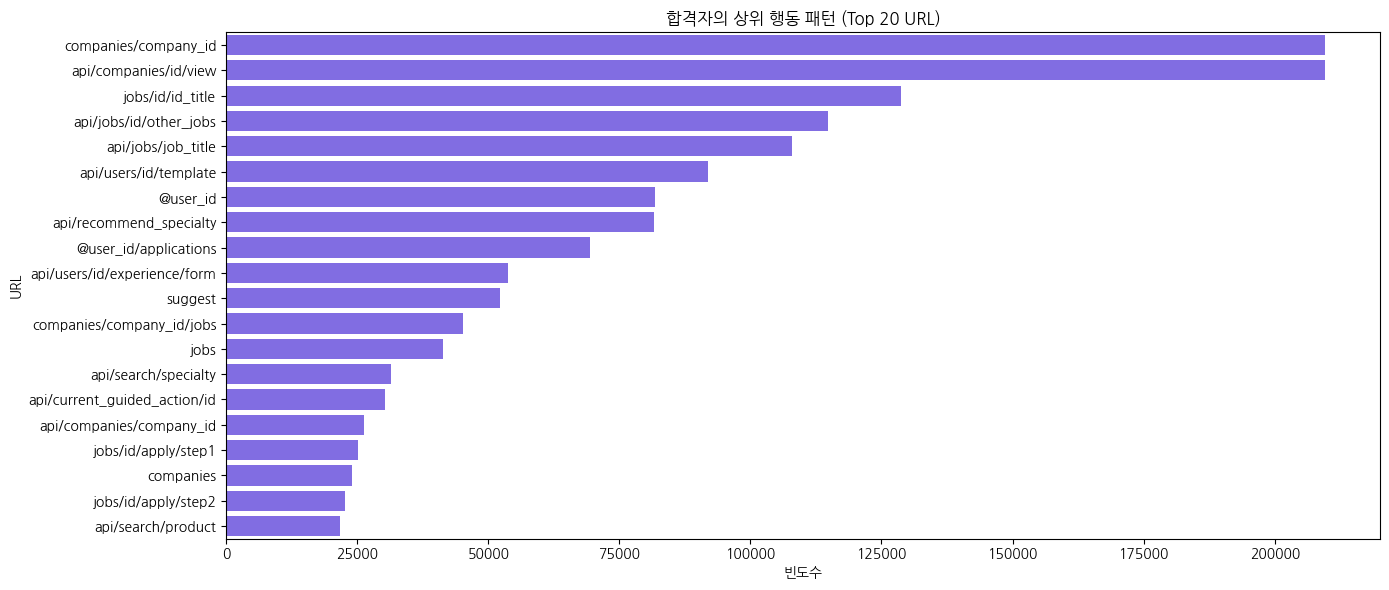

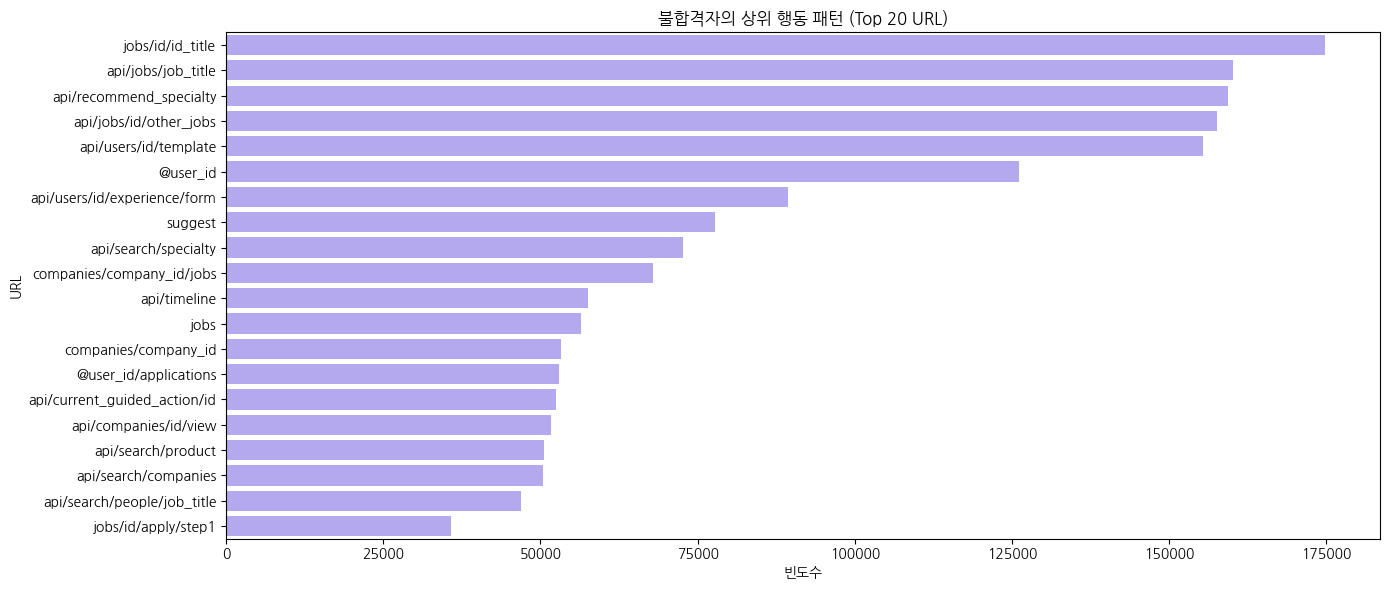

In [ ]:
plt.figure(figsize=(14, 6))
sns.barplot(data=top_passed, x='count', y='cleaned_url', color='#7459f6')
plt.title("합격자의 상위 행동 패턴 (Top 20 URL)")
plt.xlabel("빈도수")
plt.ylabel("URL")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.barplot(data=top_failed, x='count', y='cleaned_url', color='#ac9cfa')
plt.title("불합격자의 상위 행동 패턴 (Top 20 URL)")
plt.xlabel("빈도수")
plt.ylabel("URL")
plt.tight_layout()
plt.show()

## step3 후 로그 확인 (step3 경로에 도달한 후 어떤 행동을 하는가)

In [ ]:
# 유저별로 timestamp 순 정렬
log_df = log_df.sort_values(by=['user_uuid', 'timestamp'])

### step3 이후 5개

In [ ]:
# 결과 저장할 리스트
results = []

# 유저별로 그룹핑
for user, group in log_df.groupby('user_uuid'):
    group = group.reset_index(drop=True)

    # 'jobs/id/apply/step3'이 처음 등장하는 인덱스 찾기
    match_indices = group.index[group['cleaned_url'] == 'jobs/id/apply/step3'].tolist()

    for idx in match_indices:
        # 이후 10개의 로그 추출 (idx 포함해서 총 10개)
        subset = group.iloc[idx:idx+5]
        results.append(subset)

# 결과 합치기
after_step3_df = pd.concat(results, ignore_index=True)

# 결과 출력 (또는 저장 등)
after_step3_df

,Unnamed: 0,user_uuid,URL,timestamp,date,response_code,method,cleaned_url,status
0,449933,0002535c-eacb-456b-a620-92c917332ba3,jobs/id/apply/step3,2022-06-11 23:06:11.008202,2022-06-12,200,GET,jobs/id/apply/step3,기타
1,449922,0002535c-eacb-456b-a620-92c917332ba3,api/jobs/id/apply/step3,2022-06-11 23:06:16.756018,2022-06-12,400,POST,api/jobs/id/apply/step3,기타
2,449997,0002535c-eacb-456b-a620-92c917332ba3,continue?next=/@kyungmeejung/job_offer/received,2022-06-21 02:20:46.512750,2022-06-21,302,GET,continue,기타
3,449859,0002535c-eacb-456b-a620-92c917332ba3,@user_id/job_offer/received?utm_source=notific...,2022-06-21 02:20:47.094849,2022-06-21,200,GET,@user_id/job_offer/received,기타
4,450014,0002535c-eacb-456b-a620-92c917332ba3,api/job_offer/id/modal?type=received&_=1655778...,2022-06-21 02:21:01.616304,2022-06-21,200,GET,api/job_offer/id/modal,기타
...,...,...,...,...,...,...,...,...,...
586964,1776626,ffff25ca-c1d7-4fc2-891b-b0df92f95092,jobs/id/apply/step3,2023-11-29 14:23:33.639992,2023-11-29,200,GET,jobs/id/apply/step3,기타
586965,1776621,ffff25ca-c1d7-4fc2-891b-b0df92f95092,api/jobs/id/apply/step3,2023-11-29 14:23:41.449743,2023-11-29,200,POST,api/jobs/id/apply/step3,기타
586966,1776716,ffff25ca-c1d7-4fc2-891b-b0df92f95092,jobs/id/apply/step4,2023-11-29 14:23:42.002444,2023-11-29,200,GET,jobs/id/apply/step4,기타
586967,1776649,ffff25ca-c1d7-4fc2-891b-b0df92f95092,api/jobs/id/apply/step4,2023-11-29 14:23:45.753890,2023-11-29,200,POST,api/jobs/id/apply/step4,기타


In [ ]:
# step3 이후의 행동만 추출 (step3 자체는 제외)
after_only_df = after_step3_df[after_step3_df['cleaned_url'] != 'jobs/id/apply/step3']

# 행동별 전체 카운트 집계
after_step3_top10_actions = (
    after_only_df['cleaned_url']
    .value_counts()
    .reset_index()
)

# 컬럼 이름 정리
after_step3_top10_actions.columns = ['cleaned_url', 'count']

# 결과 출력
after_step3_top10_actions

,cleaned_url,count
0,api/jobs/id/apply/step3,79494
1,jobs/id/apply/step4,55964
2,api/jobs/id/apply/step4,41803
3,jobs/id/id_title,37172
4,api/jobs/id/other_jobs,21198
...,...,...
180,api/comments,1
181,api/users/id/profile_image,1
182,api/companies/id/reference/id,1
183,email_security,1


### step3 바로 직후

In [ ]:
# 결과 저장할 리스트
results = []

# 유저별로 그룹핑
for user, group in log_df.groupby('user_uuid'):
    group = group.reset_index(drop=True)

    # 'jobs/id/apply/step3'이 처음 등장하는 인덱스 찾기
    match_indices = group.index[group['cleaned_url'] == 'jobs/id/apply/step3'].tolist()

    for idx in match_indices:
        # 이후 10개의 로그 추출 (idx 포함해서 총 10개)
        subset = group.iloc[idx:idx+2]
        results.append(subset)

# 결과 합치기
next_step3_df = pd.concat(results, ignore_index=True)

# 결과 출력 (또는 저장 등)
next_step3_df

,Unnamed: 0,user_uuid,URL,timestamp,date,response_code,method,cleaned_url,status
0,449933,0002535c-eacb-456b-a620-92c917332ba3,jobs/id/apply/step3,2022-06-11 23:06:11.008202,2022-06-12,200,GET,jobs/id/apply/step3,기타
1,449922,0002535c-eacb-456b-a620-92c917332ba3,api/jobs/id/apply/step3,2022-06-11 23:06:16.756018,2022-06-12,400,POST,api/jobs/id/apply/step3,기타
2,449877,0002535c-eacb-456b-a620-92c917332ba3,jobs/id/apply/step3,2022-07-23 04:06:52.749883,2022-07-23,200,GET,jobs/id/apply/step3,기타
3,449937,0002535c-eacb-456b-a620-92c917332ba3,api/jobs/id/apply/step3,2022-07-23 04:07:41.363913,2022-07-23,200,POST,api/jobs/id/apply/step3,기타
4,449852,0002535c-eacb-456b-a620-92c917332ba3,jobs/id/apply/step3,2022-07-23 04:08:24.788796,2022-07-23,200,GET,jobs/id/apply/step3,기타
...,...,...,...,...,...,...,...,...,...
234929,1776599,ffff25ca-c1d7-4fc2-891b-b0df92f95092,api/jobs/id/apply/step3,2023-11-29 14:16:59.666569,2023-11-29,200,POST,api/jobs/id/apply/step3,기타
234930,1776609,ffff25ca-c1d7-4fc2-891b-b0df92f95092,jobs/id/apply/step3,2023-11-29 14:19:40.618461,2023-11-29,200,GET,jobs/id/apply/step3,기타
234931,1776657,ffff25ca-c1d7-4fc2-891b-b0df92f95092,api/jobs/id/apply/step3,2023-11-29 14:19:53.102233,2023-11-29,200,POST,api/jobs/id/apply/step3,기타
234932,1776626,ffff25ca-c1d7-4fc2-891b-b0df92f95092,jobs/id/apply/step3,2023-11-29 14:23:33.639992,2023-11-29,200,GET,jobs/id/apply/step3,기타


In [ ]:
# step3 이후의 행동만 추출 (step3 자체는 제외)
next_only_df = next_step3_df[next_step3_df['cleaned_url'] != 'jobs/id/apply/step3']

# 행동별 전체 카운트 집계
next_step3_top10_actions = (
    next_only_df['cleaned_url']
    .value_counts()
    .reset_index()
)

# 컬럼 이름 정리
next_step3_top10_actions.columns = ['cleaned_url', 'count']

# 결과 출력
next_step3_top10_actions

,cleaned_url,count
0,api/jobs/id/apply/step3,59631
1,jobs/id/apply/step2,11506
2,jobs/id/id_title,9299
3,jobs/id/apply/step1,3966
4,companies/company_id/jobs,3956
...,...,...
124,email_security,1
125,companies/company_id/jobs/job_title,1
126,api/users/id/language,1
127,api/references,1


# 정리

## 연도별 합격자/불합격자 행동 및 리텐션 비교

- 상위 20개 행동을 비교했을 때, 22년과 23년 모두 합격자와 불합격자 간에 차이가 일부 확인됨  
  - 22년 불합격자는 지원 관련 행동이 거의 없었음  
  - 23년 불합격자는 지원 관련 행동을 일부 보였지만, 적극적으로 지원을 완료하지는 않음  

- 지원 이후 리텐션에서는 두 연도 모두 유사한 경향을 보였으며,  
  합격자의 리텐션이 불합격자보다 consistently 높은 수준을 유지함  

- 22년과 23년 데이터를 합쳐서 보더라도 동일한 패턴이 반복됨


- 신규 회원가입을 완료하고 첫 지원을 완료한 활성화 유저에 대해 리텐션을 개선하기 위한 방안을 모색
    - 지원한 공고에 합격하면 유저에게 긍정적인 경험으로 인지됨
        - 근거: 합격자와 불합격자의 지원 완료 후 리텐션 비교
    - 공고 지원 페이지에서 합격률을 높이는 가이드라인 제시
        - 근거: step3에서 체류시간이 가장 길었음 -> step3에서 작성할 내용 가장 많음
            - 합격자와 불합격자의 step3 체류시간을 비교했을 때 합격자의 체류시간이 더 길었음 -> step3에서 더 자세하게 내용을 작성하면 합격률이 오름
    - 공고 지원 적극성 높이는 멘트 ("많은 사람이 관심을 갖는 공고예요. 지원해보세요.", "공고 마감이 얼마 남지 않았어요." 등)
        - 근거: 합격자와 불합격자의 행동을 비교하였을 때 합격자가 더 적극적으로 지원하고 지원을 완료하는 경향이 있음

## 발표 계획 (AARRR 기반 분석 및 개선 방향)

### 1. AARRR Cycle 설명
- **획득(Acquisition):** 신규 회원가입 완료  
- **활성화(Activation):** 최초 지원 완료 경험 → AHA 모먼트는 ‘지원 완료’  
- **리텐션(Retention):** 낮게 나타남 → 개선 필요  
- **수익화(Revenue):** 플랫폼을 통해 지원자가 합격하면 수수료 발생 (수익 모델 중 하나로 확인)  

---

### 2. 지원 완료자 비교 (서류 합격자 vs 불합격자)
- 활성화 유저 정의: 지원 완료 경험이 있는 유저  
- **결과:** 합격자가 불합격자보다 리텐션이 높음 → 서류 합격 경험이 긍정적 사용자 경험으로 작용  
- **서류 합격에 집중한 이유:** 면접은 플랫폼에서 통제 불가, 서류 단계는 플랫폼 내에서 직접 개입 가능  
- **추가 아이디어:** 면접 후기 작성 기능 제공 → 간접적으로 면접 가이드라인 제시 가능  

---

### 3. 합격 확률을 높이기 위한 플랫폼 개선 아이디어
- **지원 페이지 개선 (step3 중심)**  
  - Step3 체류 시간이 가장 길었으며, 합격자는 불합격자보다 더 오래 머묾  
  - → Step3에서 작성 가이드를 제공하면 합격률 향상 가능  

- **지원 적극성 유도 멘트 제공**  
  - 예: "많은 사람이 관심을 갖는 공고예요, 지원해보세요." / "공고 마감이 얼마 남지 않았습니다."  
  - 근거: 합격자는 불합격자보다 더 적극적으로 지원 및 완료하는 경향이 있음  

---

### 4. 예상 시나리오
- 개선안:  
  - 지원 페이지 내 합격률 향상 가이드 멘트 추가  
  - 지원 적극성을 높이는 팝업 메시지 제공  
- 기대 효과:  
  - 합격률 상승 → 합격자 증가 → 플랫폼 수익(수수료) 증가
